# Track Metrics Plots
Regenerates all plots from JSON data files saved alongside the PNGs.
Edit the path and style variables below, then re-run all cells.

In [8]:
%matplotlib inline
from pathlib import Path
import json
import numpy as np
import matplotlib.pyplot as plt

# ── Path to the directory containing the JSON files ───────────────────────────
PLOT_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_SegmentGNN_GT")

# ── Figure style ──────────────────────────────────────────────────────────────
FIGSIZE      = (7, 5)       # (width, height) in inches
FONT_AXIS    = 18           # axis label font size
FONT_TICK    = 14           # tick label font size
FONT_LEGEND  = 14           # legend font size
FONT_TITLE   = 18           # title font size
CAPSIZE      = 3
MARKERSIZE   = 3 
GRID_ALPHA   = 0.3
DPI          = 150          # set to None to skip saving; otherwise saves next to JSON
AUTO_XLIM    = True         # True: fit x-axis to actual data range; False: use stored xlim

# ── Segment matching specific ─────────────────────────────────────────────────
MIN_BIN_FRACTION = 0.03     # suppress bins with < this fraction of peak-bin count (segment matching plots only)

print(f"Looking for JSON files in: {PLOT_DIR}")
json_files = sorted(PLOT_DIR.glob("*.json"))
print(f"Found {len(json_files)} file(s):")
for f in json_files:
    print(f"  {f.name}")

Looking for JSON files in: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_SegmentGNN_GT
Found 10 file(s):
  clone_rate_vs_eta_testset_SegmentGNN_GT.json
  clone_rate_vs_pt_testset_SegmentGNN_GT.json
  completeness_vs_eta_testset_SegmentGNN_GT.json
  completeness_vs_pt_testset_SegmentGNN_GT.json
  efficiency_vs_eta_testset_SegmentGNN_GT.json
  efficiency_vs_pt_testset_SegmentGNN_GT.json
  matching_efficiency_eta_testset_SegmentGNN_GT.json
  matching_efficiency_pt_testset_SegmentGNN_GT.json
  purity_vs_eta_testset_SegmentGNN_GT.json
  purity_vs_pt_testset_SegmentGNN_GT.json


In [9]:
import re

def none_to_nan(lst):
    """Convert a list with None entries back to a numpy array with np.nan."""
    return np.array([np.nan if v is None else v for v in lst], dtype=float)


def _data_xlim(data: dict, pad_fraction=0.08) -> list:
    """Compute xlim from the actual x ± xerr range across all series."""
    lo, hi = np.inf, -np.inf
    for s in data.get("series", []):
        x    = none_to_nan(s["x"])
        xerr = none_to_nan(s["xerr"])
        valid = ~np.isnan(x) & ~np.isnan(s["y"] if isinstance(s["y"], np.ndarray)
                                          else none_to_nan(s["y"]))
        if not np.any(valid):
            continue
        lo = min(lo, float(np.nanmin(x[valid] - xerr[valid])))
        hi = max(hi, float(np.nanmax(x[valid] + xerr[valid])))
    if not np.isfinite(lo) or not np.isfinite(hi):
        return None
    pad = max((hi - lo) * pad_fraction, 0.02)
    return [lo - pad, hi + pad]


def _apply_min_bin_fraction(s: dict, min_bin_fraction: float) -> dict:
    """Return a copy of series s with sparse bins masked to NaN."""
    if "n" not in s:
        return s
    n = none_to_nan(s["n"])
    peak = np.nanmax(n) if np.any(~np.isnan(n)) else 1
    sparse = n < min_bin_fraction * peak
    y      = none_to_nan(s["y"]).copy()
    ylo    = none_to_nan(s["yerr_lo"]).copy()
    yhi    = none_to_nan(s["yerr_hi"]).copy()
    y[sparse] = np.nan
    ylo[sparse] = np.nan
    yhi[sparse] = np.nan
    return {**s, "y": y, "yerr_lo": ylo, "yerr_hi": yhi}


def render_plot(data: dict, figsize=FIGSIZE, save_path=None,
                min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Render one plot from its JSON data dict.

    Returns the Figure so the notebook can display or further tweak it.
    ylabel_fontsize overrides FONT_AXIS for the y-axis label only.
    ylabel overrides the label text stored in the JSON.
    """
    fig, ax = plt.subplots(figsize=figsize)

    for s in data.get("series", []):
        if min_bin_fraction is not None:
            s = _apply_min_bin_fraction(s, min_bin_fraction)
        x       = none_to_nan(s["x"])
        xerr    = none_to_nan(s["xerr"])
        y       = none_to_nan(s["y"])
        yerr_lo = none_to_nan(s["yerr_lo"])
        yerr_hi = none_to_nan(s["yerr_hi"])
        label   = re.sub(r"\s*\(.*?\)\s*$", "", s.get("label", ""))

        ax.errorbar(
            x, y,
            xerr=xerr, yerr=[yerr_lo, yerr_hi],
            fmt=s.get("marker", "o"),
            color=s.get("color", None),
            label=label,
            capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE,
        )

    ax.set_xlabel(data.get("xlabel", ""), fontsize=FONT_AXIS)
    ax.set_ylabel(ylabel if ylabel is not None else data.get("ylabel", ""),
                  fontsize=ylabel_fontsize if ylabel_fontsize is not None else FONT_AXIS)
    ax.tick_params(axis="both", labelsize=FONT_TICK)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONT_LEGEND)

    if AUTO_XLIM:
        xlim = _data_xlim(data)
        if xlim is not None:
            ax.set_xlim(xlim)
    elif "xlim" in data and data["xlim"] is not None:
        ax.set_xlim(data["xlim"])

    if "ylim" in data and data["ylim"] is not None:
        ax.set_ylim(data["ylim"])

    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    return fig


def load_and_render(json_path: Path, save_suffix="_replot",
                    min_bin_fraction=None, ylabel_fontsize=None, ylabel=None) -> plt.Figure:
    """Load JSON and render. Saves a PDF next to the JSON."""
    with open(json_path) as f:
        data = json.load(f)
    if "title" in data:
        print(data["title"])
    save_path = json_path.with_name(json_path.stem + save_suffix + ".pdf")
    return render_plot(data, save_path=save_path, min_bin_fraction=min_bin_fraction,
                       ylabel_fontsize=ylabel_fontsize, ylabel=ylabel)


print("Helper functions defined.")

Helper functions defined.


## Track Efficiency

efficiency_vs_eta_testset_SegmentGNN_GT
Track Efficiency vs ETA (Overall: 0.982)


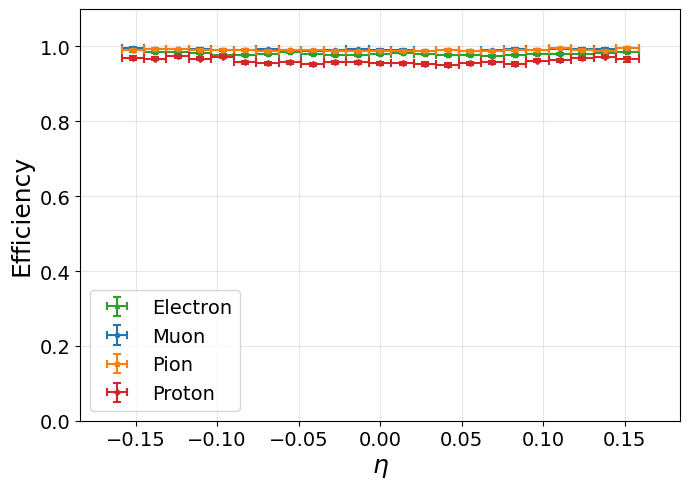

efficiency_vs_pt_testset_SegmentGNN_GT
Track Efficiency vs PT (Overall: 0.982)


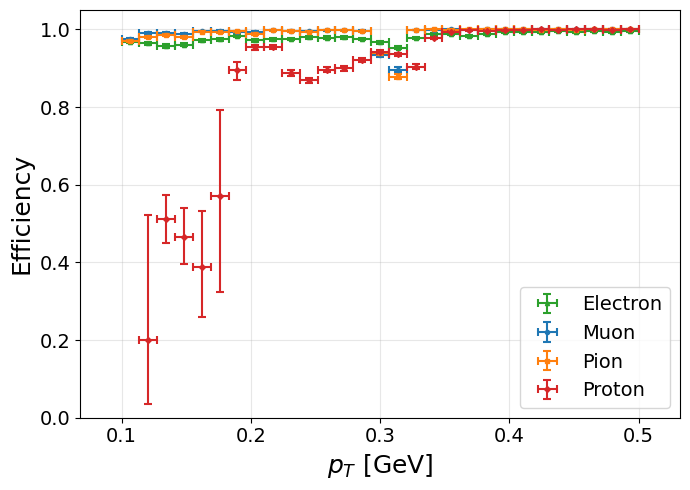

In [10]:
for p in sorted(PLOT_DIR.glob("efficiency_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Clone Rate

clone_rate_vs_eta_testset_SegmentGNN_GT
Clone Rate vs ETA (Overall: 0.000)


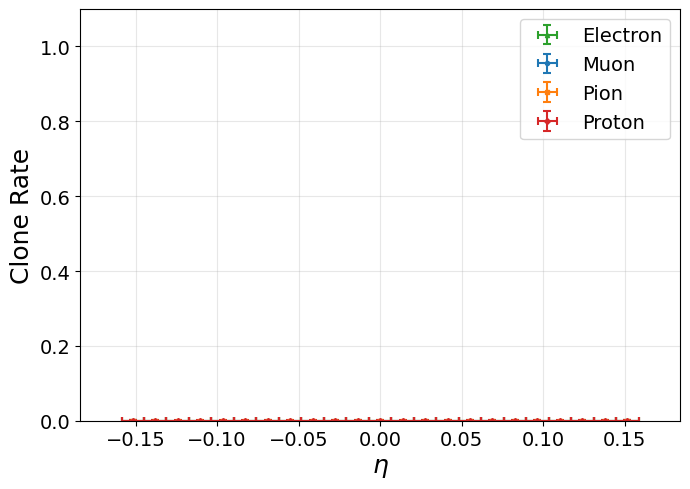

clone_rate_vs_pt_testset_SegmentGNN_GT
Clone Rate vs PT (Overall: 0.000)


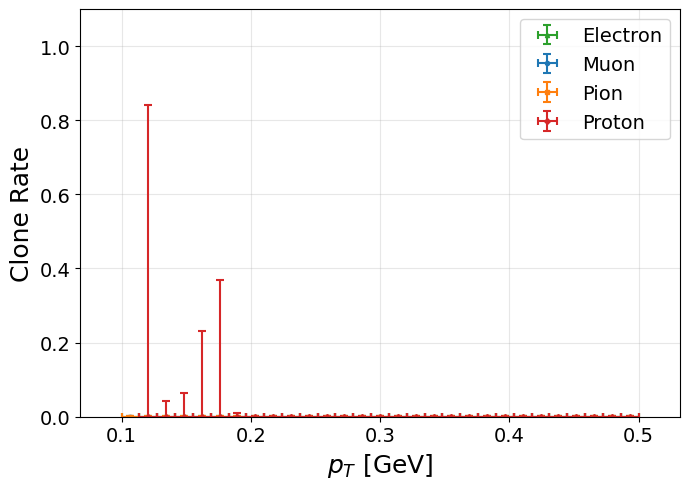

In [11]:
for p in sorted(PLOT_DIR.glob("clone_rate_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Track Purity

purity_vs_eta_testset_SegmentGNN_GT
Track Purity vs ETA (Overall: 0.984)


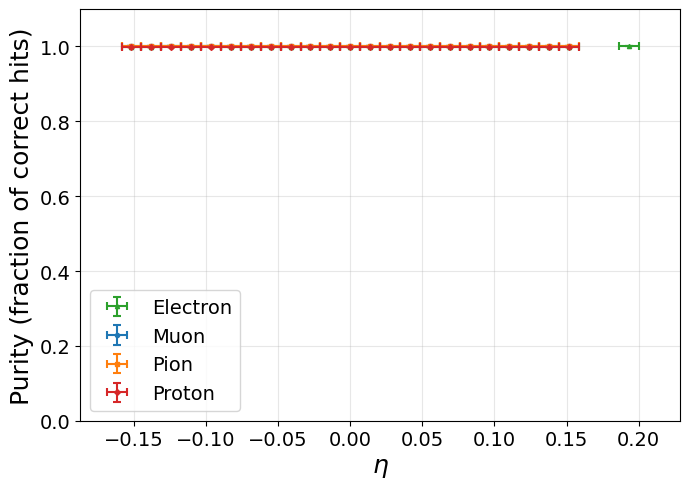

purity_vs_pt_testset_SegmentGNN_GT
Track Purity vs PT (Overall: 0.984)


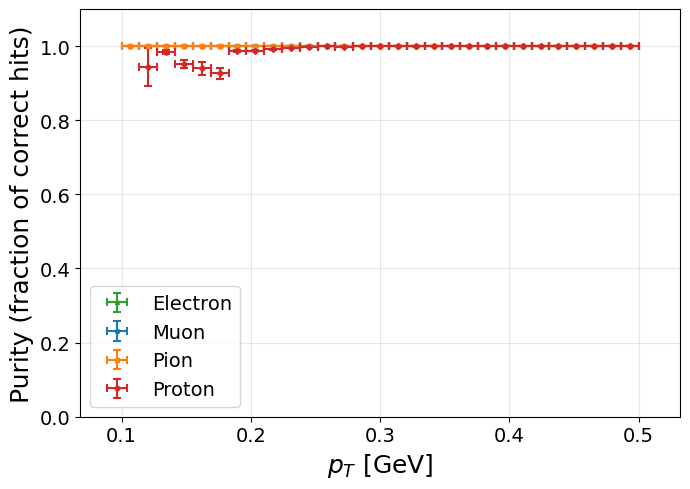

In [12]:
for p in sorted(PLOT_DIR.glob("purity_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Track Completeness

completeness_vs_eta_testset_SegmentGNN_GT
Track Completeness vs ETA (Overall: 0.952)


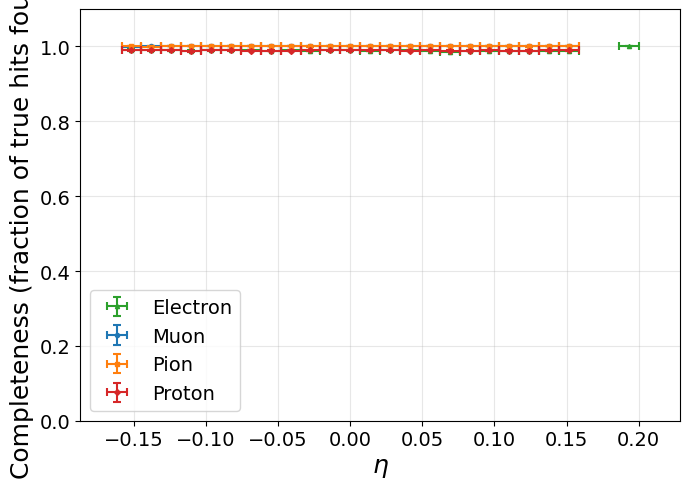

completeness_vs_pt_testset_SegmentGNN_GT
Track Completeness vs PT (Overall: 0.952)


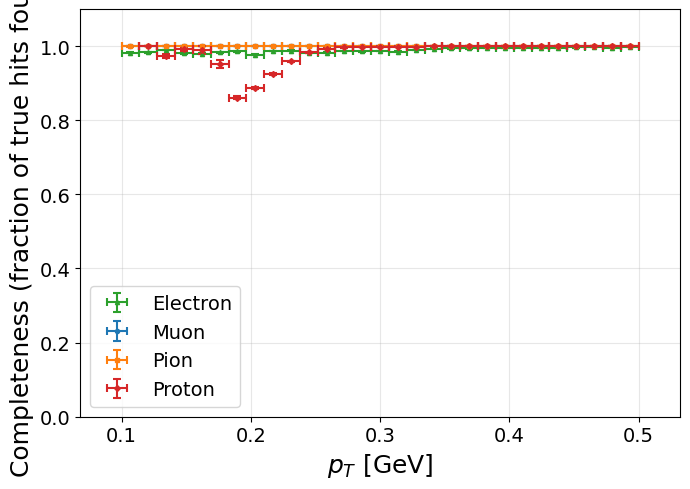

In [13]:
for p in sorted(PLOT_DIR.glob("completeness_vs_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Segment Matching Efficiency

matching_efficiency_eta_testset_SegmentGNN_GT
Segment Matching Efficiency vs η (Overall: 0.936)


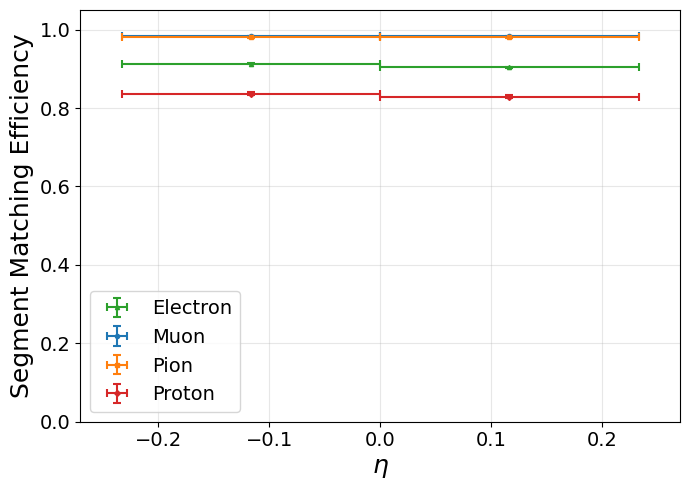

matching_efficiency_pt_testset_SegmentGNN_GT
Segment Matching Efficiency (Overall: 0.936)


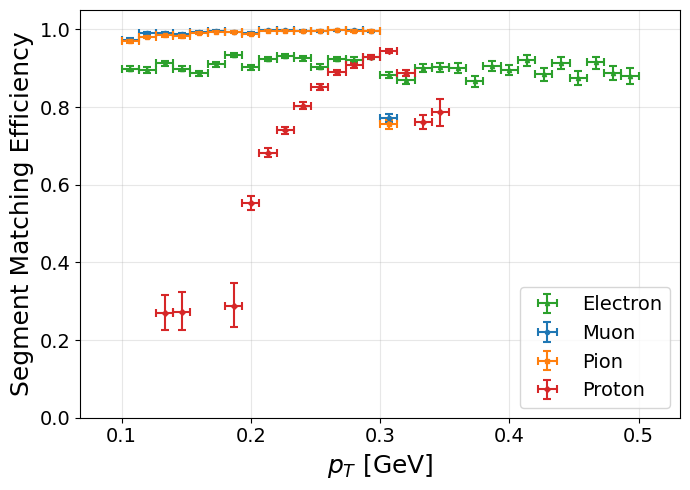

In [14]:
for p in sorted(PLOT_DIR.glob("matching_efficiency_*.json")):
    print(p.stem)
    fig = load_and_render(p, min_bin_fraction=MIN_BIN_FRACTION)
    plt.show()


## Segment-level Plots (efficiency / purity / completeness)

In [15]:
for p in sorted(PLOT_DIR.glob("segment_*.json")):
    print(p.stem)
    fig = load_and_render(p)
    plt.show()


## Any remaining JSON files

In [16]:
known_patterns = [
    "efficiency_vs_*.json",
    "clone_rate_vs_*.json",
    "purity_vs_*.json",
    "completeness_vs_*.json",
    "matching_efficiency_*.json",
    "segment_*.json",
]
already_shown = set()
for pat in known_patterns:
    already_shown.update(PLOT_DIR.glob(pat))

remaining = [p for p in sorted(PLOT_DIR.glob("*.json")) if p not in already_shown]
if remaining:
    for p in remaining:
        print(p.stem)
        fig = load_and_render(p)
        plt.show()
else:
    print("All JSON files covered by the sections above.")

All JSON files covered by the sections above.


## GT Segments per Particle vs pT

In [17]:
import torch
import pandas as pd

FEATURE_STORE_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data/feature_store/testset")
GT_SEG_OUT = PLOT_DIR / "gt_segments_per_particle_vs_pt.pdf"

PDG_MAP     = {11: "Electron", 13: "Muon", 211: "Pion", 2212: "Proton"}
SPEC_COLORS = {"Electron": "#2ca02c", "Muon": "#1f77b4", "Pion": "#ff7f0e", "Proton": "#d62728"}
SPEC_MARKERS= {"Electron": "^", "Muon": "o", "Pion": "s", "Proton": "D"}

rows = []
for path in sorted(FEATURE_STORE_DIR.glob("*.pyg")):
    g = torch.load(path, weights_only=False)
    pid   = g.hit_particle_id.numpy()
    segid = g.hit_segment_id.numpy()
    tpid  = g.track_particle_id.numpy()
    tpt   = g.track_particle_pt.numpy()
    ttype = g.track_particle_type.numpy()
    pt_map      = dict(zip(tpid, tpt))
    species_map = dict(zip(tpid, ttype))
    df = pd.DataFrame({"particle_id": pid, "segment_id": segid})
    df = df[df["particle_id"] != 0]
    per_particle = df.groupby("particle_id").agg(
        n_segs=("segment_id", "nunique"),
        n_hits=("segment_id", "count"),
    ).reset_index()
    per_particle["pt"]      = per_particle["particle_id"].map(pt_map)
    per_particle["abs_pdg"] = per_particle["particle_id"].map(species_map).abs()
    per_particle = per_particle.dropna(subset=["pt", "abs_pdg"])
    per_particle["abs_pdg"] = per_particle["abs_pdg"].astype(int)
    per_particle["species"] = per_particle["abs_pdg"].map(PDG_MAP).fillna("Other")
    per_particle["file"] = str(path)
    rows.append(per_particle)

segs_df = pd.concat(rows, ignore_index=True)
print(f"Loaded {len(segs_df)} particle entries from {len(rows)} graphs")
print(segs_df.groupby("species")["n_segs"].value_counts().sort_index())

Loaded 386400 particle entries from 1001 graphs
species  n_segs
Pion     1         189461
         2         196939
Name: count, dtype: int64


Mean GT segments per particle vs pT
Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_SegmentGNN_GT/gt_segments_per_particle_vs_pt.pdf


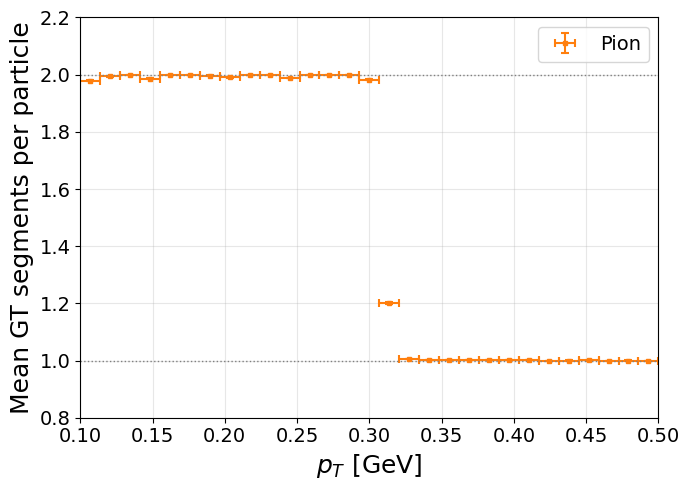

In [18]:
pt_bins = np.linspace(0.1, 0.5, 30)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

fig, ax = plt.subplots(figsize=FIGSIZE)

for species in ["Electron", "Muon", "Pion", "Proton"]:
    sub = segs_df[segs_df["species"] == species]
    if sub.empty:
        continue
    means, errs = [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = sub[(sub["pt"] >= lo) & (sub["pt"] < hi)]["n_segs"]
        if len(b) == 0:
            means.append(np.nan); errs.append(np.nan)
        else:
            means.append(b.mean())
            errs.append(b.std() / np.sqrt(len(b)))
    ax.errorbar(xc, means, xerr=xe, yerr=errs,
                fmt=SPEC_MARKERS[species], color=SPEC_COLORS[species],
                capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE, lw=1.5,
                label=species)

ax.axhline(1.0, color="gray", linestyle=":", lw=1)
ax.axhline(2.0, color="gray", linestyle=":", lw=1)
ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Mean GT segments per particle", fontsize=FONT_AXIS)
ax.tick_params(axis="both", labelsize=FONT_TICK)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0.8, 2.2)
ax.legend(fontsize=FONT_LEGEND)
ax.grid(True, alpha=GRID_ALPHA)
fig.tight_layout()

print("Mean GT segments per particle vs pT")
fig.savefig(GT_SEG_OUT, bbox_inches="tight")
print(f"Saved: {GT_SEG_OUT}")
plt.show()

Looping fraction vs pT
Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_SegmentGNN_GT/loop_fraction_vs_pt.pdf


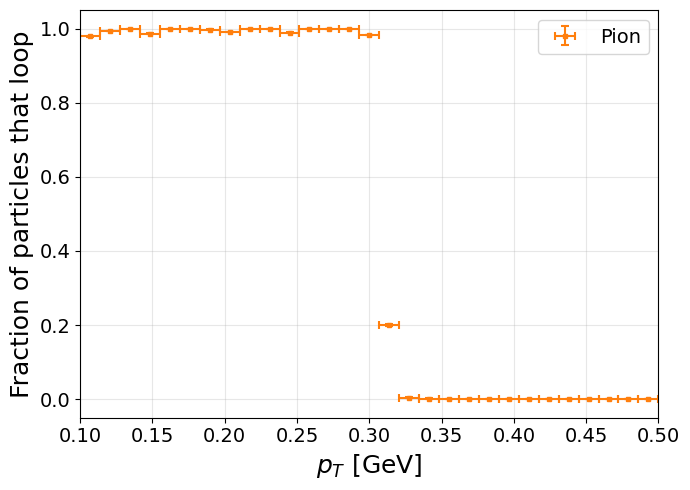

In [19]:
LOOP_FRAC_OUT = PLOT_DIR / "loop_fraction_vs_pt.pdf"

pt_bins = np.linspace(0.1, 0.5, 30)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

fig, ax = plt.subplots(figsize=FIGSIZE)

for species in ["Electron", "Muon", "Pion", "Proton"]:
    sub = segs_df[segs_df["species"] == species]
    if sub.empty:
        continue
    fracs, errs = [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = sub[(sub["pt"] >= lo) & (sub["pt"] < hi)]["n_segs"]
        if len(b) == 0:
            fracs.append(np.nan); errs.append(np.nan)
        else:
            looped = (b >= 2).mean()
            fracs.append(looped)
            errs.append(np.sqrt(looped * (1 - looped) / len(b)))
    ax.errorbar(xc, fracs, xerr=xe, yerr=errs,
                fmt=SPEC_MARKERS[species], color=SPEC_COLORS[species],
                capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE, lw=1.5,
                label=species)

ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Fraction of particles that loop", fontsize=FONT_AXIS)
ax.tick_params(axis="both", labelsize=FONT_TICK)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=FONT_LEGEND)
ax.grid(True, alpha=GRID_ALPHA)
fig.tight_layout()

print("Looping fraction vs pT")
fig.savefig(LOOP_FRAC_OUT, bbox_inches="tight")
print(f"Saved: {LOOP_FRAC_OUT}")
plt.show()

Mean hits per particle vs pT
Saved: /data/alice/bkuipers/low_pt_gnn_pipeline/data_300_mixed/visuals/track_metrics/testset_SegmentGNN_GT/mean_hits_per_particle_vs_pt.pdf


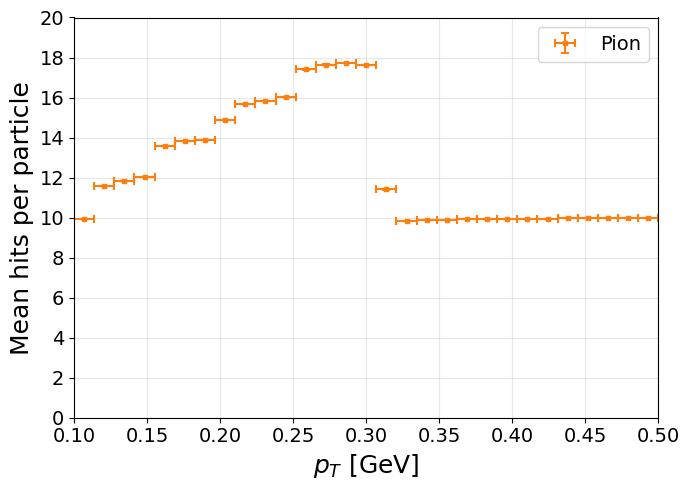

In [20]:
NHITS_OUT = PLOT_DIR / "mean_hits_per_particle_vs_pt.pdf"

pt_bins = np.linspace(0.1, 0.5, 30)
xc = (pt_bins[1:] + pt_bins[:-1]) / 2
xe = (pt_bins[1:] - pt_bins[:-1]) / 2

fig, ax = plt.subplots(figsize=FIGSIZE)

for species in ["Electron", "Muon", "Pion", "Proton"]:
    sub = segs_df[segs_df["species"] == species]
    if sub.empty:
        continue
    means, errs = [], []
    for lo, hi in zip(pt_bins[:-1], pt_bins[1:]):
        b = sub[(sub["pt"] >= lo) & (sub["pt"] < hi)]["n_hits"]
        if len(b) == 0:
            means.append(np.nan); errs.append(np.nan)
        else:
            means.append(b.mean())
            errs.append(b.std() / np.sqrt(len(b)))
    ax.errorbar(xc, means, xerr=xe, yerr=errs,
                fmt=SPEC_MARKERS[species], color=SPEC_COLORS[species],
                capsize=CAPSIZE, capthick=1.5, markersize=MARKERSIZE, lw=1.5,
                label=species)

ax.set_xlabel(r"$p_T$ [GeV]", fontsize=FONT_AXIS)
ax.set_ylabel("Mean hits per particle", fontsize=FONT_AXIS)
ax.tick_params(axis="both", labelsize=FONT_TICK)
ax.set_xlim(0.1, 0.5)
ax.set_ylim(0, 20)
ax.set_yticks(range(0, 21, 2))
ax.legend(fontsize=FONT_LEGEND)
ax.grid(True, alpha=GRID_ALPHA)
fig.tight_layout()

print("Mean hits per particle vs pT")
fig.savefig(NHITS_OUT, bbox_inches="tight")
print(f"Saved: {NHITS_OUT}")
plt.show()


In [21]:
# Diagnostic: why do high-pT electrons appear to loop?
# Checks hit-by-hit trajectory for electrons >= 0.35 GeV with n_segs >= 2.
# Uses the file stored in segs_df so we always load the correct event.

PT_THRESHOLD = 0.35  # GeV
N_EXAMPLES   = 6

suspects = segs_df[
    (segs_df["species"] == "Electron") &
    (segs_df["pt"] >= PT_THRESHOLD) &
    (segs_df["n_segs"] >= 2)
].copy()
print(f"{len(suspects)} high-pT electrons with n_segs>=2 found")

shown = 0
for _, row in suspects.iterrows():
    if shown >= N_EXAMPLES:
        break
    pid  = int(row["particle_id"])
    path = Path(row["file"])
    g = torch.load(path, weights_only=False)

    mask = g.hit_particle_id.numpy() == pid
    r    = g.hit_r.numpy()[mask]
    z    = g.hit_z.numpy()[mask]
    t    = g.hit_t.numpy()[mask]
    seg  = g.hit_segment_id.numpy()[mask]

    order = np.argsort(t)
    r, z, t, seg = r[order], z[order], t[order], seg[order]

    print(f"\n--- particle_id={pid}  pt={row['pt']:.3f} GeV  n_segs={int(row['n_segs'])}")
    print(f"    file: {path.name}")
    header = f"  {'hit':>3s}  {'t[ps]':>9s}  {'r[mm]':>8s}  {'z[mm]':>8s}  seg"
    print(header)
    for i, (ri, zi, ti, si) in enumerate(zip(r, z, t, seg)):
        marker = "  <-- seg boundary" if i > 0 and si != seg[i-1] else ""
        print(f"  {i:>3d}  {ti:>9.2f}  {ri:>8.1f}  {zi:>8.1f}  {int(si)}{marker}")
    shown += 1


0 high-pT electrons with n_segs>=2 found


## Segment Evaluation (evaluate_segments.py output)
Purity, completeness, efficiency and perfect-purity/completeness of CC/Wrangler segments before the matching stage. JSON files written by `evaluate_segments.py`.

In [ ]:
SEG_EVAL_DIR = Path("/data/alice/bkuipers/low_pt_gnn_pipeline/data/visuals/segment_evaluation/testset")

json_files = sorted(SEG_EVAL_DIR.glob("*.json"))
print(f"Found {len(json_files)} file(s) in {SEG_EVAL_DIR.name}/:")
for f in json_files:
    print(f"  {f.name}")

Found 10 file(s) in testset/:
  segment_completeness_eta_testset.json
  segment_completeness_testset.json
  segment_efficiency_eta_testset.json
  segment_efficiency_testset.json
  segment_perfect_completeness_eta_testset.json
  segment_perfect_completeness_testset.json
  segment_perfect_purity_eta_testset.json
  segment_perfect_purity_testset.json
  segment_purity_eta_testset.json
  segment_purity_testset.json


: 

: 

### Segment Finding Efficiency

Segment Finding Efficiency vs η (Overall: 1.000)


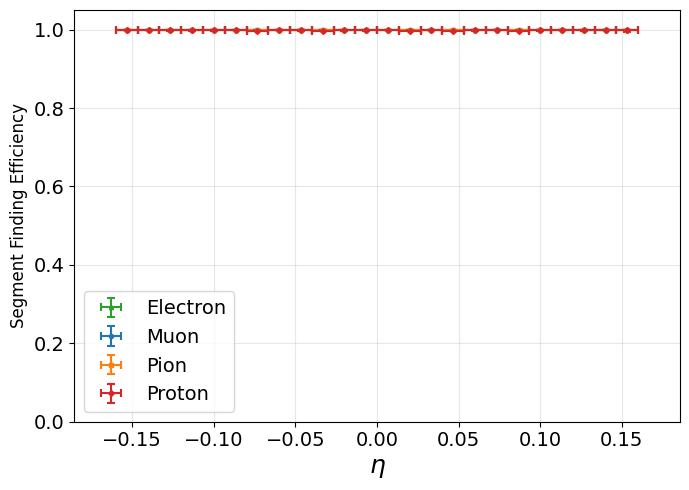

Segment Finding Efficiency (Overall: 1.000)


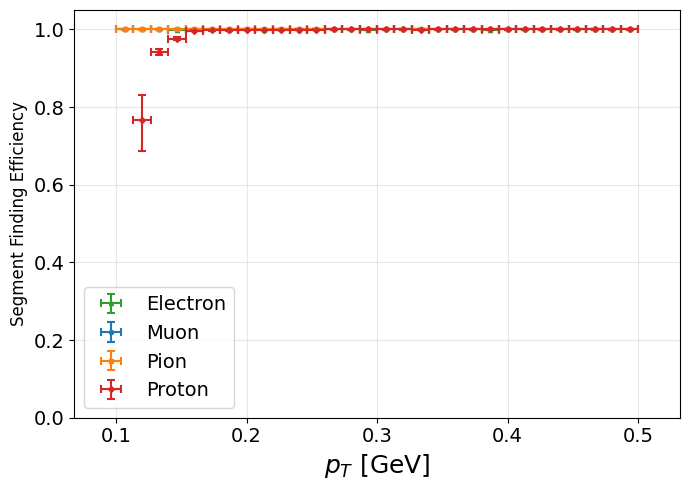

: 

: 

In [ ]:
for p in sorted(SEG_EVAL_DIR.glob("segment_efficiency_*.json")):
    fig = load_and_render(p, ylabel_fontsize=12)
    plt.show()

### Segment Purity & Completeness

Segment Purity vs η (Overall: 0.986)


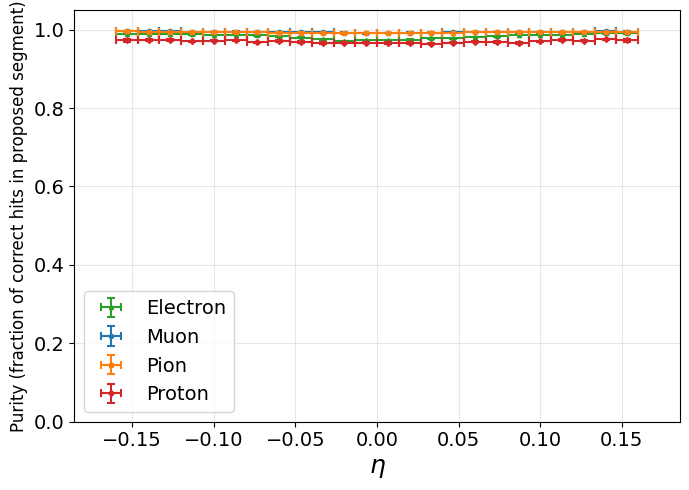

Segment Purity (Overall: 0.986)


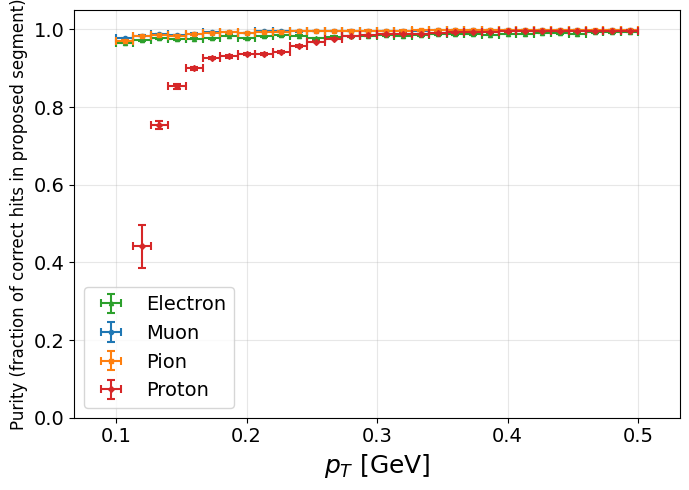

Segment Completeness vs η (Overall: 0.977)


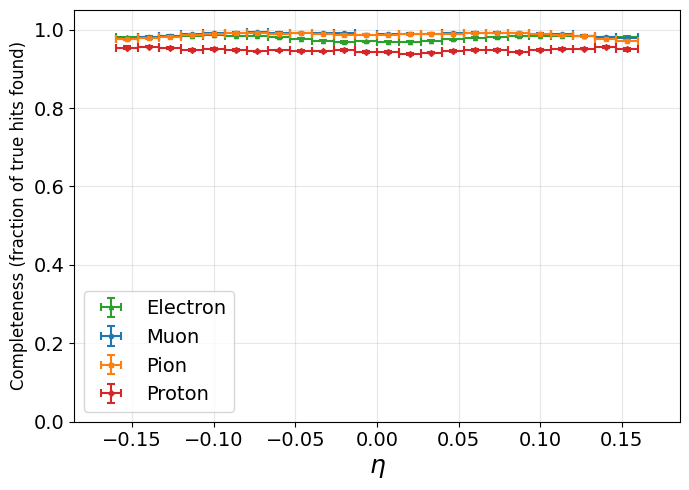

Segment Completeness (Overall: 0.977)


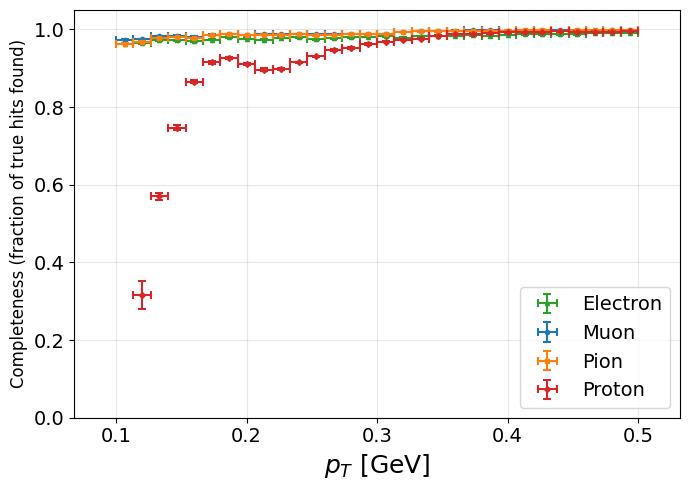

: 

: 

In [ ]:
for p in sorted(SEG_EVAL_DIR.glob("segment_purity_*.json")) + sorted(SEG_EVAL_DIR.glob("segment_completeness_*.json")):
    fig = load_and_render(p, ylabel_fontsize=12)
    plt.show()

### Perfect Purity & Perfect Completeness

Segment Perfect Purity vs η (Overall: 0.939)


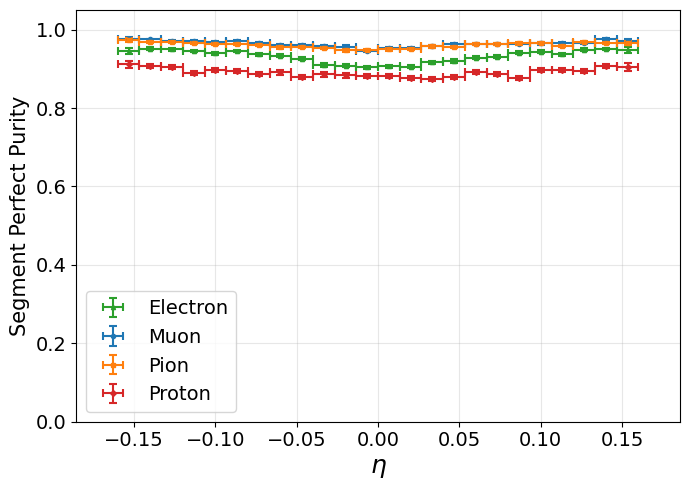

Segment Perfect Purity (Overall: 0.939)


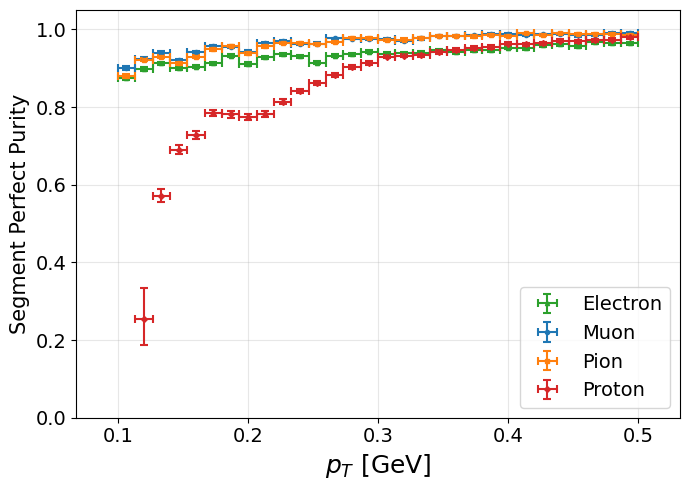

Segment Perfect Completeness vs η (Overall: 0.897)


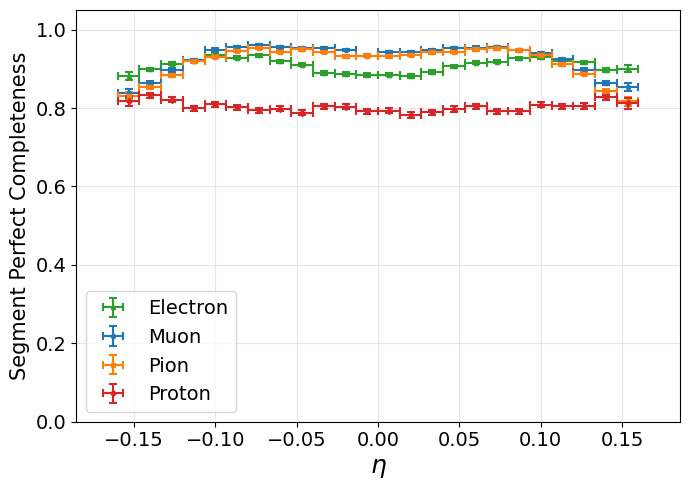

Segment Perfect Completeness (Overall: 0.897)


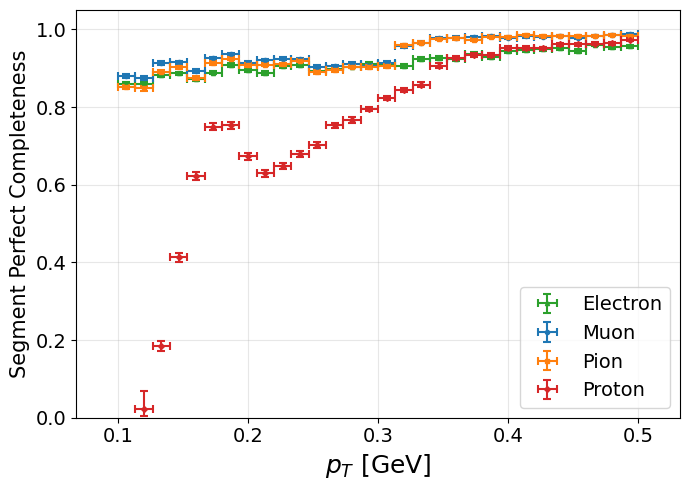

: 

: 

In [ ]:
PERFECT_YLABEL = {
    "purity":       "Segment Perfect Purity",
    "completeness": "Segment Perfect Completeness",
}

for p in sorted(SEG_EVAL_DIR.glob("segment_perfect_purity_*.json")) + sorted(SEG_EVAL_DIR.glob("segment_perfect_completeness_*.json")):
    key = "purity" if "purity" in p.stem else "completeness"
    fig = load_and_render(p, ylabel_fontsize=15, ylabel=PERFECT_YLABEL[key])
    plt.show()

: 

: 

: 

: 

## Out-of-Distribution Efficiency vs Multiplicity

Tracking efficiency as a function of event multiplicity (number of particles per event).
The vertical dotted line marks the training multiplicity (~300 particles/event).
Each JSON file corresponds to a different track builder configuration.

Segment GNN (CC segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_segmentGNN.pdf


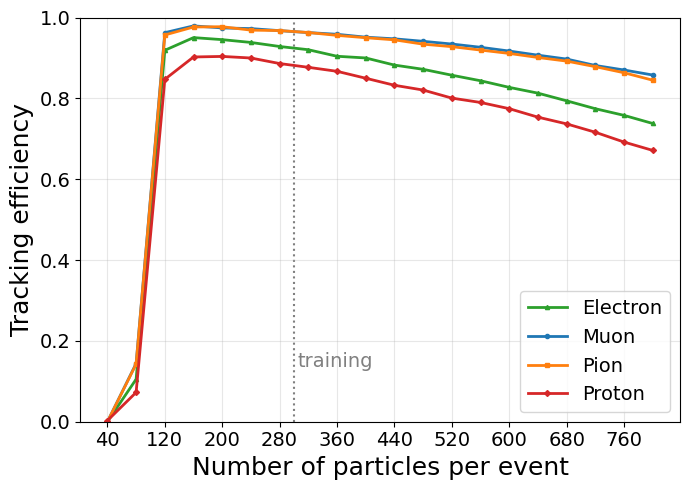

Segment GNN (GT segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_segment_GNN_GT.pdf


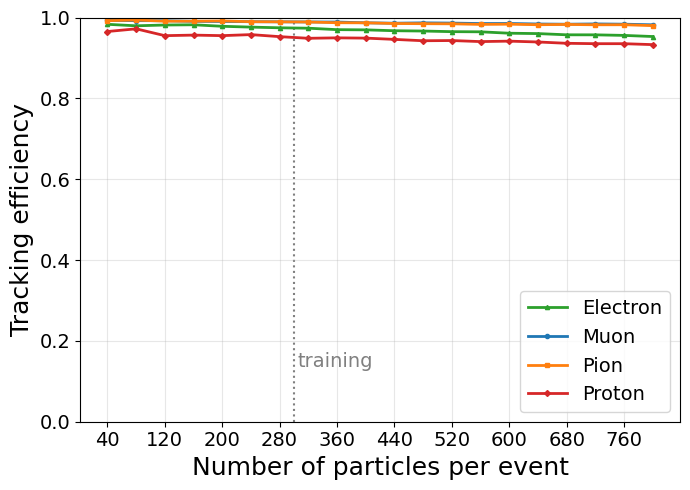

Helix matching (CC segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_helix.pdf


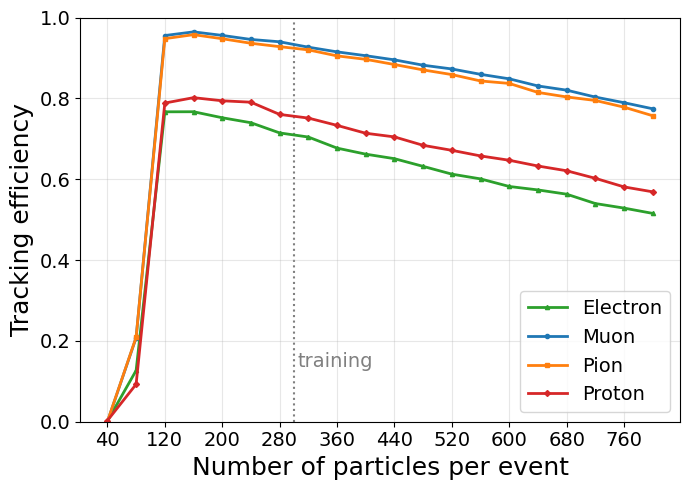

Helix matching (GT segments)
Saved: /data/alice/bkuipers/out_of_distribution_experiment/ood_efficiency_data_helix_GT.pdf


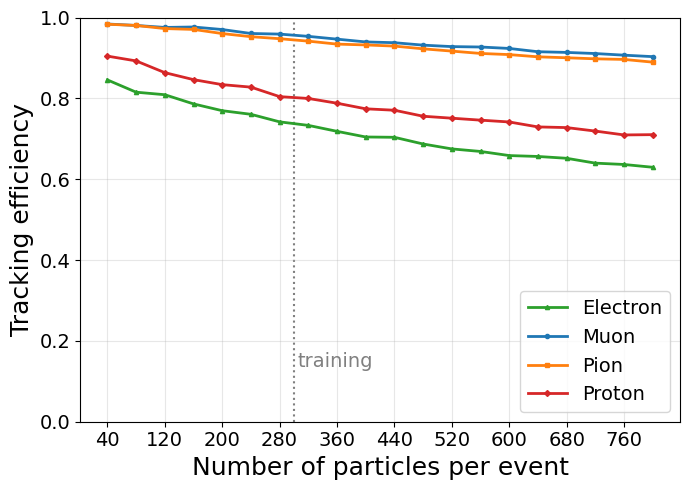

: 

: 

In [ ]:
OOD_DIR = Path("/data/alice/bkuipers/out_of_distribution_experiment")

OOD_FILES = {
    "Segment GNN (CC segments)":    OOD_DIR / "ood_efficiency_data_segmentGNN.json",
    "Segment GNN (GT segments)":    OOD_DIR / "ood_efficiency_data_segment_GNN_GT.json",
    "Helix matching (CC segments)": OOD_DIR / "ood_efficiency_data_helix.json",
    "Helix matching (GT segments)": OOD_DIR / "ood_efficiency_data_helix_GT.json",
}

SPECIES_COLORS  = {"Muon": "#1f77b4", "Pion": "#ff7f0e", "Electron": "#2ca02c", "Proton": "#d62728"}
SPECIES_MARKERS = {"Muon": "o", "Pion": "s", "Electron": "^", "Proton": "D"}

for title, json_path in OOD_FILES.items():
    if not json_path.exists():
        print(f"Missing: {json_path}"); continue
    with open(json_path) as f:
        cache = json.load(f)

    print(title)
    fig, ax = plt.subplots(figsize=FIGSIZE)
    for name, d in sorted(cache["per_species"].items()):
        ax.plot(d["x"], [e / 100 for e in d["eff"]],
                marker=SPECIES_MARKERS.get(name, "o"),
                color=SPECIES_COLORS.get(name, "gray"),
                lw=2, markersize=MARKERSIZE, label=name)

    ax.axvline(300, color="gray", lw=1.5, linestyle=":", zorder=0)
    ax.text(305, 0.15, "training", ha="left", va="center", fontsize=FONT_LEGEND, color="gray")
    ax.set_xlabel("Number of particles per event", fontsize=FONT_AXIS)
    ax.set_ylabel("Tracking efficiency", fontsize=FONT_AXIS)
    ax.tick_params(labelsize=FONT_TICK)
    ax.set_xticks(cache["overall"]["x"][::2])
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=GRID_ALPHA)
    ax.legend(fontsize=FONT_LEGEND, loc="lower right")
    fig.tight_layout()

    out_path = json_path.with_suffix(".pdf")
    fig.savefig(out_path, bbox_inches="tight", dpi=DPI)
    print(f"Saved: {out_path}")
    plt.show()


: 

: 

: 

: 